In [93]:
import os
from skimage import color, io, measure, img_as_ubyte, segmentation, morphology
from skimage.measure import profile_line
from skimage.transform import rescale, resize
from skimage.morphology import binary_closing, binary_opening
import matplotlib.pyplot as plt
import numpy as np
import pydicom as dicom
import math
from skimage.util import img_as_float
from skimage.util import img_as_ubyte
from skimage.filters import (
    threshold_otsu,
    median,
    gaussian,
    prewitt_h,
    prewitt_v,
    prewitt,
)
from skimage.color import rgb2gray, label2rgb
from scipy.ndimage import correlate
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import norm
from scipy.spatial import distance

# Wine

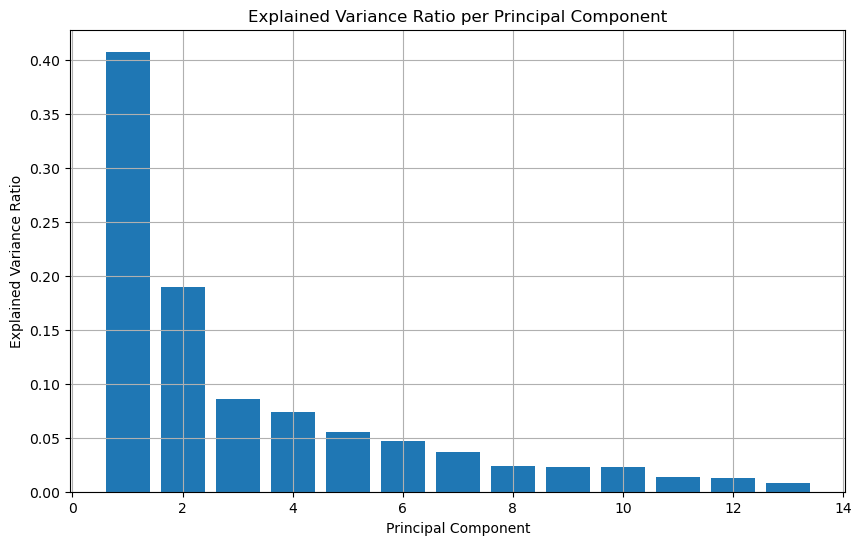

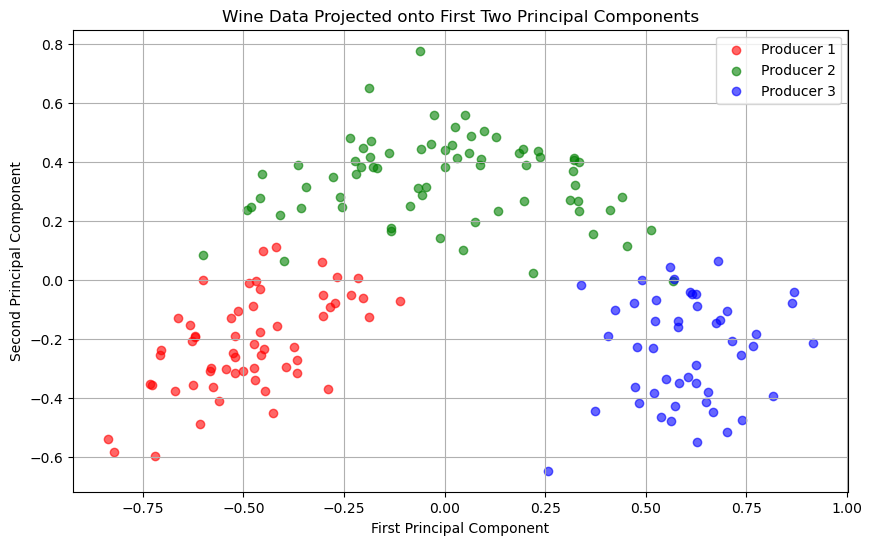

Explained variance ratio for each component:
PC1: 0.4075 (40.75%)
PC2: 0.1897 (18.97%)
PC3: 0.0856 (8.56%)
PC4: 0.0743 (7.43%)
PC5: 0.0557 (5.57%)
PC6: 0.0466 (4.66%)
PC7: 0.0366 (3.66%)
PC8: 0.0241 (2.41%)
PC9: 0.0227 (2.27%)
PC10: 0.0225 (2.25%)
PC11: 0.0138 (1.38%)
PC12: 0.0127 (1.27%)
PC13: 0.0082 (0.82%)

Cumulative explained variance ratio for first two components: 0.5972 (59.72%)


In [94]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
x_org = np.loadtxt("winePCA/wine-data.txt", comments="%")
x = x_org[:, :13]  # Measurements
producer = x_org[:, 13]  # Producer labels

# Step 1: Scale the data
# Subtract mean
x_mean = np.mean(x, axis=0)
x_centered = x - x_mean

# Divide by range (max - min)
x_range = np.max(x, axis=0) - np.min(x, axis=0)
x_scaled = x_centered / x_range

# Step 2: PCA
# Compute covariance matrix
cov_matrix = np.cov(x_scaled.T)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Project data onto principal components
projected_data = np.dot(x_scaled, eigenvectors)

# Plotting results
# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio per Principal Component")
plt.grid(True)
plt.show()

# Scatter plot of first two principal components colored by producer
plt.figure(figsize=(10, 6))
colors = ["r", "g", "b"]
for prod in [1, 2, 3]:
    mask = producer == prod
    plt.scatter(
        projected_data[mask, 0],
        projected_data[mask, 1],
        c=colors[int(prod) - 1],
        label=f"Producer {int(prod)}",
        alpha=0.6,
    )
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("Wine Data Projected onto First Two Principal Components")
plt.legend()
plt.grid(True)
plt.show()

# Print some useful information
print("Explained variance ratio for each component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")
print(
    f"\nCumulative explained variance ratio for first two components: "
    f"{sum(explained_variance_ratio[:2]):.4f} "
    f"({sum(explained_variance_ratio[:2])*100:.2f}%)"
)

After projection to PCA space the wines from producer 1 and producer 2 are
compared. The average projected value on the first principal component is computed
for the wines from producer 1 and from producer 2. What is the difference between
the two average values?

In [95]:
producer1_mask = producer == 1
producer2_mask = producer == 2
avg_pc1_prod1 = np.mean(projected_data[producer1_mask, 0])
avg_pc1_prod2 = np.mean(projected_data[producer2_mask, 0])
diff = avg_pc1_prod1 - avg_pc1_prod2
diff


np.float64(-0.4827369984140581)

ANS: Between 0.30 and 0.50

After projection to PCA space, the coordinates of the wines in PCA space is examined.
The minimum and maximum projected coordinates on the first principal component
is found and the difference is computed. What is it?

In [96]:
pc_first = projected_data[:, 0]
np.max(pc_first) - np.min(projected_data[:, 0])

np.float64(1.7509334569362713)

Ans: Between 1 and 2

What is the alcohol level of the first wine after normalization (subtraction of mean and
division by max-min)

In [97]:
x_scaled[0]

array([ 0.32352158, -0.12378425,  0.03394821, -0.2007703 ,  0.29628725,
        0.17409919,  0.21745366, -0.15444138,  0.22053663,  0.04965103,
        0.06711428,  0.47923612,  0.22689497])

Ans: between 0.30 and 0.40

What is the average value of the elements in the covariance matrix?

In [98]:
cov_matrix.shape
np.average(cov_matrix)

np.float64(0.006240233570354023)

Ans: between 0.006 and 0.008

How many percent of the total variation in the data set is explained by the first five
principal components?
Ans:Between 80% and 85%

# Flower design
A newly formed company, Bulbz, has approached you and asked you to help with their new line of
flowers. They have provided you with 15 photos of their flower named flower01.jpg to flower15.jpg.
They would like you to use a data driven approach, principal component analysis (PCA) to analyze their
flowers.
You start by computing an average flower image and then the PCA from sklearn.decomposition to
compute 5 principal components from the flower images. You also project all the flower images onto
the principal components to find their positions in PCA space.

In [99]:
def create_u_byte_image_from_vector(im_vec, height, width, channels):
    min_val = im_vec.min()
    max_val = im_vec.max()

    # Transform to [0, 1]
    im_vec = np.subtract(im_vec, min_val)
    im_vec = np.divide(im_vec, max_val - min_val)
    im_vec = im_vec.reshape(height, width, channels)
    im_out = img_as_ubyte(im_vec)
    return im_out

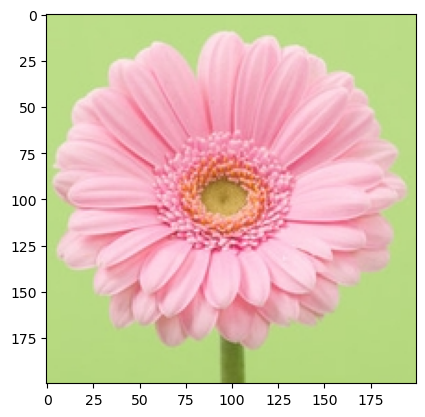

In [100]:
img = io.imread("flowers/flower01.jpg")
plt.imshow(img), img.shape
img_height = img.shape[0]
img_width = img.shape[1]
img_channels = img.shape[2]

/tmp/ipykernel_130418/2170818341.py:39: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(mean_img)


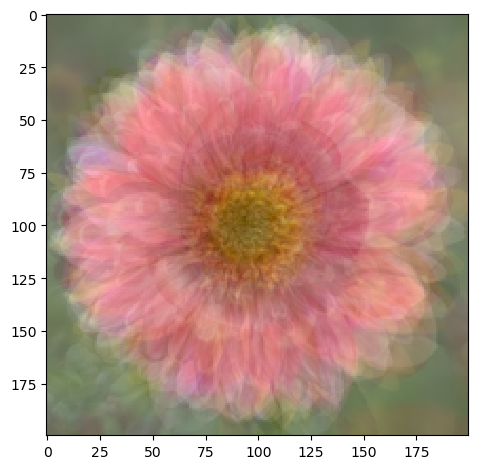

In [101]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os

# Define image parameters (adjust based on actual images)
n_images = 15
n_components = 5  # Number of principal components
image_dir = "flowers/"  # Directory with images

# Placeholder image file names (replace with actual paths)
image_files = [f"flower{str(i + 1).zfill(2)}.jpg" for i in range(n_images)]

# Load images into a data matrix
data_matrix = []
for file_name in image_files:
    file_path = os.path.join(image_dir, file_name)
    try:
        # Load image, convert to grayscale, resize if needed
        img = io.imread(file_path)
        # Flatten image to 1D array (100x100 = 10,000 pixels)
        img_array = np.array(img).flatten()
        data_matrix.append(img_array)
    except FileNotFoundError:
        print(f"Error: Image {file_path} not found. Please provide correct paths.")
        exit()

# Convert list to numpy array (20 images x 10,000 pixels)
data_matrix = np.array(data_matrix)  # Shape: (20, 10000)

# Compute the average image
average_image = np.mean(data_matrix, axis=0)  # Shape: (10000,)
mean_img = create_u_byte_image_from_vector(
    average_image,
    img_height,
    img_width,
    img_channels,
)
io.imshow(mean_img)

In [102]:
# Center the data (subtract mean from each image)
# Apply PCA to compute 5 principal components
image_pca = PCA(n_components=n_components)
image_pca.fit(data_matrix)

# Get the 5 principal components
principal_components = image_pca.components_  # Shape: (5, 10000)
explained_variance_ratio = (
    image_pca.explained_variance_ratio_
)  # Variance explained by each component

# Project images into PCA space
pca_coordinates = image_pca.transform(
    data_matrix
)  # Shape: (20, 5), 5D coordinates for each image

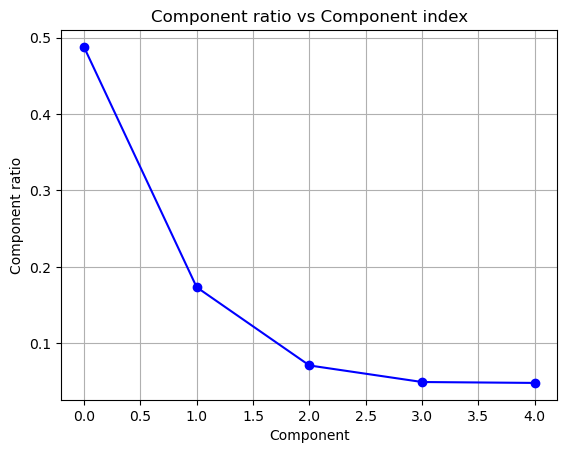

Explained Variance Ratio for 5 Principal Components:
[0.4879 0.1732 0.0708 0.0491 0.048 ]


In [103]:
plt.plot(
    list(range(len(explained_variance_ratio))),
    explained_variance_ratio,
    marker="o",
    linestyle="-",
    color="b",
)
plt.title("Component ratio vs Component index")
plt.xlabel("Component")
plt.ylabel("Component ratio")
plt.grid(True)
plt.show()


# Print results
print("Explained Variance Ratio for 5 Principal Components:")
print(np.round(explained_variance_ratio, 4))

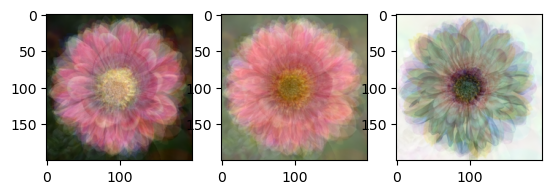

In [104]:
synth_image_plus = create_u_byte_image_from_vector(
    average_image + 3 * np.sqrt(image_pca.explained_variance_[0]) * image_pca.components_[0, :],
    img_height,
    img_width,
    img_channels,
)
synth_image_minus =  create_u_byte_image_from_vector(
    average_image - 3 * np.sqrt(image_pca.explained_variance_[0]) * image_pca.components_[0, :],
    img_height,
    img_width,
    img_channels,
)
fig, axes = plt.subplots(1, 3)
axes[0].imshow(synth_image_minus)
axes[1].imshow(mean_img)
axes[2].imshow(synth_image_plus)

You want to explore the major visual variation in the data set. To do that you
synthesize two flower images by following the direction of the first principal
component. You can for example do that by:
Ans: The color of the flower

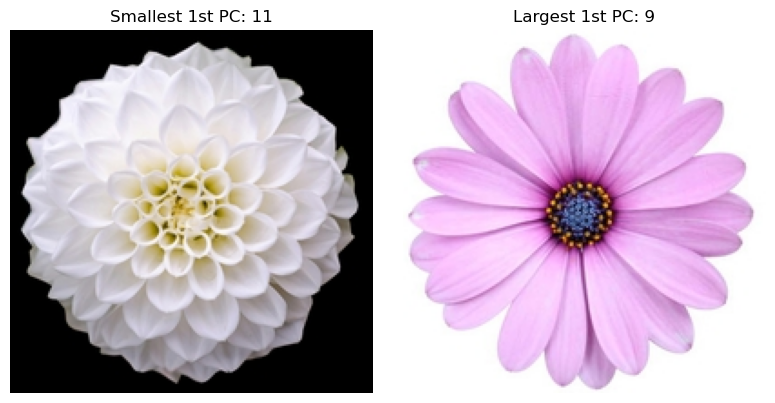

In [105]:
first_pc = pca_coordinates[:, 0]
min_pc_idx = np.argmin(first_pc)
max_pc_idx = np.argmax(first_pc)
indexes = [min_pc_idx, max_pc_idx]
in_dir = "flowers/"
image_files = [f"flower{str(idx).zfill(2)}.jpg" for idx in indexes]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(io.imread(in_dir + image_files[0]))
axes[0].set_title(f"Smallest 1st PC: {min_pc_idx}")
axes[0].axis("off")
axes[1].imshow(io.imread(in_dir + image_files[1]))
axes[1].set_title(f"Largest 1st PC: {max_pc_idx}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Ans: Do not know?

FIRST PC: Between 40% and 50%

In [106]:
# Load and preprocess idealflower.jpg
ideal_file = "flowers/idealflower.jpg"
try:
    ideal_img = io.imread(ideal_file)  # Load as grayscale

    ideal_array = ideal_img.flatten()  # Shape: (10000,)
except FileNotFoundError:
    print(f"Error: Image {ideal_file} not found.")
    exit()

# Center idealflower.jpg
ideal_centered = ideal_array - average_image  # Shape: (10000,)

# Project idealflower.jpg onto PCA space
ideal_pca = image_pca.transform(ideal_centered.reshape(1, -1))  # Shape: (1, 5)

# Extract second principal component
ideal_second_component = ideal_pca[0, 1]  # Scalar
flowers_second_component = pca_coordinates[:, 1]  # Shape: (15,)

# Compute distances (absolute differences) on second component
distances = np.abs(flowers_second_component - ideal_second_component)

# Find the index of the closest flower
closest_idx = np.argmin(distances)
print(closest_idx)


3


Ans : Sunflower


# Spine analysis
The first step in diagnosing spine related diseases is to locate and segment the individual elements of
the spine - the vertebras. To develop a segmentation algorithm, we first try with a single DICOM slice (1-
353.dcm) to get an idea of the appearance of the vertebra.
An expert has also created a mask (vertebra_gt.png) of the vertebra seen in the DICOM slice.
We start by reading the DICOM file and extracting the pixel values (in Hounsfield units).
Bone has a high x-ray attenuation and we manually select a threshold, so all pixel with HU value above
200 are set to foreground and the rest of the pixels are set to background. To remove small noise
structures, a morphological closing with a disk-shaped structuring element (radius=3) is performed on
the binary image.
We do a BLOB analysis of the cleaned binary image to be able to recognize the vertebra. The area
(number of pixels) of all the found BLOBs are computed. Finally, only the BLOBs with an area larger
than 500 pixels are kept. We consider this the result of our segmentation algorithm.

In [107]:
in_dir = "vertebraCT/"
im_name = "1-353.dcm"
ds = dicom.dcmread(in_dir + im_name)
im = ds.pixel_array

/tmp/ipykernel_130418/2174248012.py:35: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(vert_mask)
/home/monkescripts/anaconda3/envs/image_analysis/lib/python3.13/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


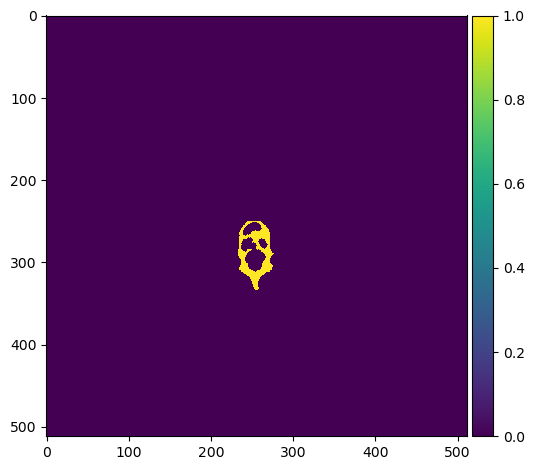

In [108]:
import pydicom
import numpy as np
from scipy.ndimage import label
from skimage.measure import regionprops
from skimage.morphology import disk, closing

# Create binary image with thresholding
binary_im = (im > 200).astype(np.uint8)

# Perform BLOB analysis


# Filter BLOBS based on perimeter and area
# min_perimeter = 400
# max_perimeter = 600
# max_area = 5000
structuring_element = disk(3)
closed_img = closing(binary_im, structuring_element)
min_area = 500
labeled_im, num_blobs = label(closed_img)
props = regionprops(labeled_im)
vert_blobs = []
for prop in props:
    area = prop.area  # Number of pixels in the BLOB
    perimeter = prop.perimeter  # Perimeter of the BLOB
    if area >= min_area :
        vert_blobs.append(prop)

# Create a binary image with only the kidney BLOBS
vert_mask = np.zeros_like(binary_im)
for blob in vert_blobs:
    vert_mask[labeled_im == blob.label] = 1

# Apply morphological closing
io.imshow(vert_mask)

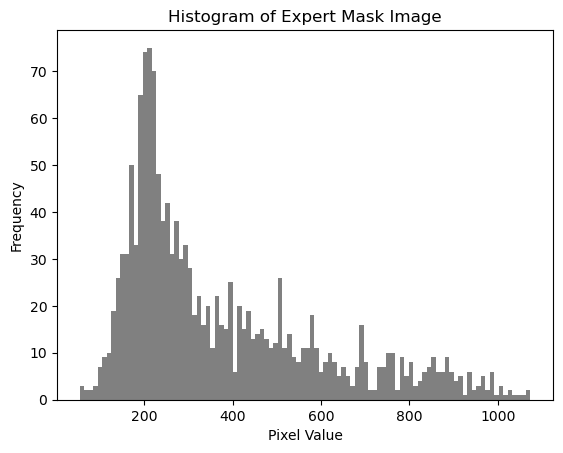

In [109]:
expert_mask = io.imread("vertebraCT/vertebra_gt.png")
hu_values = im[vert_mask == 1]
plt.hist(hu_values.ravel(), bins=100, color='gray')
plt.title("Histogram of Expert Mask Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

In [110]:
std = np.std(hu_values)
mean_hu = np.mean(hu_values)
std, mean_hu

(np.float64(223.79913867096596), np.float64(373.6496250852079))

Ans: Average is in [350, 400] and standard deviation is in [220, 230]

In [111]:
areas = []
for prop in props:
    area = prop.area  # Number of pixels in the BLOB
    areas.append(area)
areas = np.asarray(areas)
np.min(areas), np.max(areas)

(np.float64(1.0), np.float64(1467.0))

Ans: Minimum is in [0, 10] and maximum is in [1000, 1500]

In [112]:
ground_truth_img = io.imread(in_dir + "vertebra_gt.png")
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(vert_mask.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

DICE score 0.7307596513075965


Ans: Between 0.70 and 0.75

# Zebra stripe
A scientist wants to investigate the morphology of zebra stripes and their possible genetic relation and
has collected many images of zebras. As an image analysis expert, you are asked to establish a twoclass parametric pixel classification algorithm. \
Class 1 contains the white stripes and class 2 the black
stripes. 
The zebra expert has manually drawn regions of interest (ROI) on a zebra image (Zebra.png)
indicating which pixels to use for training. \
Two binary masks are provided. One with examples of white stripes (Zebra_whiteStripes.png) and one
with example of black stripes (Zebra_blackStripes.png). \
Using the original image and the masks, train the parametric classifier and find the optimal threshold
to separate white and black stripes. \
The original image is stored as a one-channel gray scale image and should not be converted from RGB.

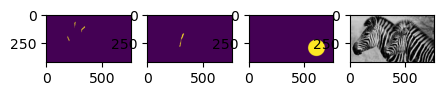

In [113]:
in_dir = "zebra/"
black_roi = io.imread(in_dir + "Zebra_blackStripes.png")
white_roi = io.imread(in_dir + "Zebra_whiteStripes.png")
expert_mask = io.imread(in_dir + "Zebra_MASK.png")
original_img = io.imread(in_dir + "Zebra.png")
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(5, 5))
axes[0].imshow(white_roi)
axes[1].imshow(black_roi)
axes[2].imshow(expert_mask)
axes[3].imshow(original_img)
plt.show()

In [114]:
import scipy.stats as stats

In [115]:
def parametric(dist1, dist2):
    mu1, std1 = dist1[0], dist1[1]
    mu2, std2 = dist2[0], dist2[1]
    x1 = np.linspace(mu1 - 3 * std1, mu1 + 3 * std1, 1000)
    x2 = np.linspace(mu2 - 3 * std2, mu2 + 3 * std2, 1000)
    plt.plot(x1, stats.norm.pdf(x1, mu1, std1))
    plt.plot(x2, stats.norm.pdf(x2, mu2, std2))

    # Found by inspecting the plot and seeing where the Gaussian crosses
    for i in range(int(min(x1.min(), x2.min())), int(max(x1.max(), x2.max()))):
        if stats.norm.pdf(i, mu1, std1) < stats.norm.pdf(i, mu2, std2):
            print(f"Parametric threshold: {i-1}/{i}")
            highest = max(
                np.max(stats.norm.pdf(x1, mu1, std1)),
                np.max(stats.norm.pdf(x2, mu2, std2)),
            )
            plt.vlines(i - 1, 0, highest, colors=["r"])
            break

    plt.show()

Parametric threshold: 124/125


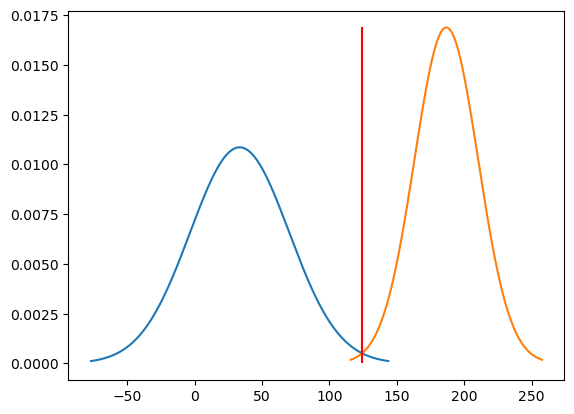

(None, (np.float64(186.61915367483297), np.float64(23.631962580548727)))

In [116]:
masked_white = original_img[white_roi > 0]
masked_black = original_img[black_roi > 0]
mu1, std1 = masked_white.mean(), masked_white.std()
mu2, std2 = masked_black.mean(), masked_black.std()

dist1 = (mu1, std1)
dist2 = (mu2, std2)

parametric(dist2, dist1), dist1

In [117]:
original_img.shape

(423, 755, 3)

In [118]:
# Get grayscale image if needed (your original_img is shape (423, 755, 3))
# Apply mask
zebra_pixels = original_img[expert_mask > 0]
# Classify as white stripe if pixel value > 124
num_white_pixels = np.sum(zebra_pixels > 124)
print(f"Number of white stripe pixels: {num_white_pixels}")
zebra_pixels.shape

Number of white stripe pixels: 15420


(16871, 3)

# Ans: Dont know

[0, 124]

What are the parameters (mean and standard deviation) of the Gaussian distribution
for the trained classifier for the white stripes?
Mean is in range [180, 190] and standard deviation is in range [20, 30]

# Gradient descent
To find the optimal translation, a gradient descent optimization algorithm is used. The starting guess is
and a constant step length of 0.07 is used.

After 6 steps: x1 0.26 x2 0.18 c 0.14
After 7 steps: x1 0.22 x2 0.12 c 0.08
After 8 steps: x1 0.19 x2 0.09 c 0.05
After 9 steps: x1 0.16 x2 0.06 c 0.03
After 10 steps: x1 0.14 x2 0.05 c 0.02
After 11 steps: x1 0.12 x2 0.04 c 0.02
After 12 steps: x1 0.10 x2 0.03 c 0.01
After 13 steps: x1 0.09 x2 0.02 c 0.01
After 14 steps: x1 0.07 x2 0.02 c 0.01
After 15 steps: x1 0.06 x2 0.02 c 0.00
After 16 steps: x1 0.06 x2 0.01 c 0.00
After 17 steps: x1 0.05 x2 0.01 c 0.00
After 18 steps: x1 0.04 x2 0.01 c 0.00
After 19 steps: x1 0.04 x2 0.01 c 0.00
After 20 steps: x1 0.03 x2 0.01 c 0.00
After 21 steps: x1 0.03 x2 0.01 c 0.00
After 22 steps: x1 0.02 x2 0.01 c 0.00
After 23 steps: x1 0.02 x2 0.01 c 0.00
After 24 steps: x1 0.02 x2 0.00 c 0.00
After 25 steps: x1 0.02 x2 0.00 c 0.00
After 26 steps: x1 0.01 x2 0.00 c 0.00
After 27 steps: x1 0.01 x2 0.00 c 0.00
After 28 steps: x1 0.01 x2 0.00 c 0.00
After 29 steps: x1 0.01 x2 0.00 c 0.00
After 30 steps: x1 0.01 x2 0.00 c 0.00


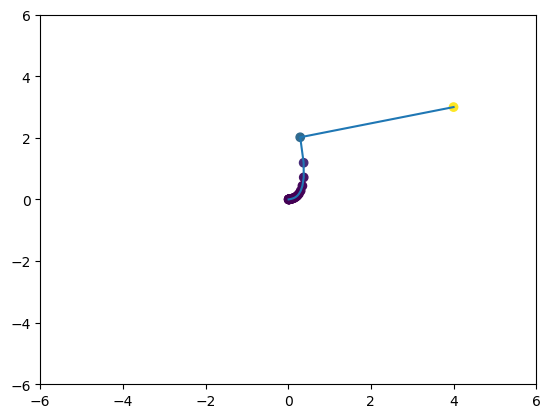

In [119]:
def gradient_descent_e_2024():
    x_1_start = 4
    x_2_start = 3
    step_length = 0.07

    n_steps = 30
    x_1 = x_1_start
    x_2 = x_2_start
    cs = []
    x_1_s = []
    x_2_s = []
    for i in range(n_steps):
        x_1_s.append(x_1)
        x_2_s.append(x_2)

        grad_x_1 = 2 * x_1 - x_2 + 3 * (x_1 ** 2)
        grad_x_2 = -x_1 + 6 * x_2

        new_x_1 = x_1 - step_length * grad_x_1
        new_x_2 = x_2 - step_length * grad_x_2
        x_1 = new_x_1
        x_2 = new_x_2
        c = x_1 **2 - x_1 * x_2 + 3 * (x_2 ** 2) + x_1 ** 3
        if c < 0.2:
            print(f"After {i+1} steps: x1 {x_1:.2f} x2 {x_2:.2f} c {c:.2f}")

        cs.append(c)
    # plt.plot(cs)
    # plt.show()

    plt.scatter(x_1_s, x_2_s, c=cs)
    plt.plot(x_1_s, x_2_s)
    plt.xlim([-6, 6])
    plt.ylim([-6, 6])
    plt.show()


gradient_descent_e_2024()

After 5 iterations: Between 0.25 and 0.50

After 6 steps

# Sorting plastic using LDA
A computer vision system is used to sort plastic into two types (class 1 and class 2). Each camera looks
at a piece of plastic and computes an overall number based on the color and shape of the plastic piece.
That means that there is only two numbers for each piece of plastics. We can plot these values into a 2-
dimensional features space (x1, x2).
You are asked to train a linear discriminant analysis (LDA) classifier to see if you can create an optimal
hyperplane separating the two types of plastic into class 1 and class 2. You have (previously, not used
in theses questions) been provided with 100 samples from each class and you have found out that each
class have a prior probability of 0.5. Class 1 has a mean value of (24, 3) and class 2 has a mean value of
(45, 7). The covariance matrix for both classes is: [[2, 0], [0, 2]]

x₂ = -5.25x₁ + 186.125
-1.7, 2 idk

# Image registration

In [120]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from skimage.util import img_as_ubyte
from IPython.display import clear_output

In [121]:
def imshow_orthogonal_view(sitkImage, origin=None, title=None):
    """
    Display the orthogonal views of a 3D volume from the middle of the volume.

    Parameters
    ----------
    sitkImage : SimpleITK image
        Image to display.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left
    """
    data = sitk.GetArrayFromImage(sitkImage)

    if origin is None:
        origin = np.array(data.shape) // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    data = img_as_ubyte(data / np.max(data))
    axes[0].imshow(data[origin[0], ::-1, ::-1], cmap="gray")
    axes[0].set_title("Axial")

    axes[1].imshow(data[::-1, origin[1], ::-1], cmap="gray")
    axes[1].set_title("Coronal")

    axes[2].imshow(data[::-1, ::-1, origin[2]], cmap="gray")
    axes[2].set_title("Sagittal")

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)


def overlay_slices(sitkImage0, sitkImage1, origin=None, title=None):
    """
    Overlay the orthogonal views of a two 3D volume from the middle of the volume.
    The two volumes must have the same shape. The first volume is displayed in red,
    the second in green.

    Parameters
    ----------
    sitkImage0 : SimpleITK image
        Image to display in red.
    sitkImage1 : SimpleITK image
        Image to display in green.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left"""
    vol0 = sitk.GetArrayFromImage(sitkImage0)
    vol1 = sitk.GetArrayFromImage(sitkImage1)

    if vol0.shape != vol1.shape:
        raise ValueError("The two volumes must have the same shape.")
    if (
        np.min(vol0) < 0 or np.min(vol1) < 0
    ):  # Remove negative values - Relevant for the noisy images
        vol0[vol0 < 0] = 0
        vol1[vol1 < 0] = 0
    if origin is None:
        origin = np.array(vol0.shape) // 2

    sh = vol0.shape
    # min_val = np.min([np.min(vol0), np.min(vol1)])
    # max_val = np.max([np.max(vol0), np.max(vol1)])
    R = img_as_ubyte(vol0 / np.max(vol0))
    G = img_as_ubyte(vol1 / np.max(vol1))

    vol_rgb = np.zeros(shape=(sh[0], sh[1], sh[2], 3), dtype=np.uint8)
    vol_rgb[:, :, :, 0] = R
    vol_rgb[:, :, :, 1] = G

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(vol_rgb[origin[0], ::-1, ::-1, :])
    axes[0].set_title("Axial")

    axes[1].imshow(vol_rgb[::-1, origin[1], ::-1, :])
    axes[1].set_title("Coronal")

    axes[2].imshow(vol_rgb[::-1, ::-1, origin[2], :])
    axes[2].set_title("Sagittal")

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)

In [122]:
def composite2affine(composite_transform, result_center=None):
    """
    Combine all of the composite transformation's contents to form an equivalent affine transformation.
    Args:
        composite_transform (SimpleITK.CompositeTransform): Input composite transform which contains only
                                                            global transformations, possibly nested.
        result_center (tuple,list): The desired center parameter for the resulting affine transformation.
                                    If None, then set to [0,...]. This can be any arbitrary value, as it is
                                    possible to change the transform center without changing the transformation
                                    effect.
    Returns:
        SimpleITK.AffineTransform: Affine transformation that has the same effect as the input composite_transform.

    Source:
        https://github.com/InsightSoftwareConsortium/SimpleITK-Notebooks/blob/master/Python/22_Transforms.ipynb
    """
    # Flatten the copy of the composite transform, so no nested composites.
    flattened_composite_transform = sitk.CompositeTransform(composite_transform)
    flattened_composite_transform.FlattenTransform()
    tx_dim = flattened_composite_transform.GetDimension()
    A = np.eye(tx_dim)
    c = np.zeros(tx_dim) if result_center is None else result_center
    t = np.zeros(tx_dim)
    for i in range(flattened_composite_transform.GetNumberOfTransforms() - 1, -1, -1):
        curr_tx = flattened_composite_transform.GetNthTransform(i).Downcast()
        # The TranslationTransform interface is different from other
        # global transformations.
        if curr_tx.GetTransformEnum() == sitk.sitkTranslation:
            A_curr = np.eye(tx_dim)
            t_curr = np.asarray(curr_tx.GetOffset())
            c_curr = np.zeros(tx_dim)
        else:
            A_curr = np.asarray(curr_tx.GetMatrix()).reshape(tx_dim, tx_dim)
            c_curr = np.asarray(curr_tx.GetCenter())
            # Some global transformations do not have a translation
            # (e.g. ScaleTransform, VersorTransform)
            get_translation = getattr(curr_tx, "GetTranslation", None)
            if get_translation is not None:
                t_curr = np.asarray(get_translation())
            else:
                t_curr = np.zeros(tx_dim)
        A = np.dot(A_curr, A)
        t = np.dot(A_curr, t + c - c_curr) + t_curr + c_curr - c

    return sitk.AffineTransform(A.flatten(), t, c)

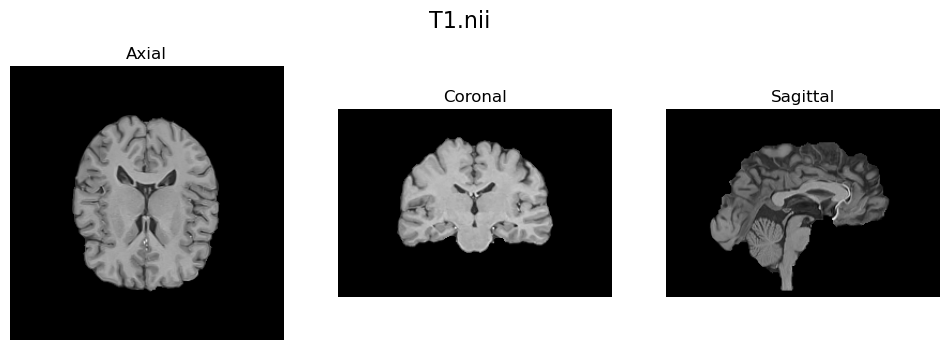

In [123]:
dir_in = "brain/"
template_sitk = sitk.ReadImage(dir_in + "T1_brain_template.nii.gz")
# Display the volume
imshow_orthogonal_view(template_sitk, title="T1.nii")
template_np = sitk.GetArrayFromImage(template_sitk)

In [124]:
from skimage.morphology import ball, closing, erosion

In [125]:
otsu_threshold = threshold_otsu(template_np)
mask_np = template_np > otsu_threshold
# Step 2: Morphological closing with ball (radius 5)
struct_elem_closing = ball(radius=5)
mask_np = closing(mask_np, struct_elem_closing)

# Step 3: Erosion with ball (radius 3)
struct_elem_erosion = ball(radius=3)
mask_np = erosion(mask_np, struct_elem_erosion)

# Convert mask to float for multiplication (0s and 1s)
mask_np = mask_np.astype(np.float32)

You apply a rigid registration to “T1_brain_template” to generate your first test. The rigid transform is
composed of a rotation with a yaw of 10 degrees followed by a pitch of -30 degrees. The output will be
the moving image for your tests.

In [126]:
def rotation_matrix(pitch, roll, yaw, deg=False):
    """
    Return the rotation matrix associated with the Euler angles roll, pitch, yaw.

    Parameters
    ----------
    pitch : float
        The rotation angle around the x-axis.
    roll : float
        The rotation angle around the y-axis.
    yaw : float
        The rotation angle around the z-axis.
    deg : bool, optional
        If True, the angles are given in degrees. If False, the angles are given
        in radians. Default: False.
    """
    if deg:
        roll = np.deg2rad(roll)
        pitch = np.deg2rad(pitch)
        yaw = np.deg2rad(yaw)

    R_x = np.array(
        [
            [1, 0, 0, 0],
            [0, np.cos(pitch), -np.sin(pitch), 0],
            [0, np.sin(pitch), np.cos(pitch), 0],
            [0, 0, 0, 1],
        ]
    )

    R_y = np.array(
        [
            [np.cos(roll), 0, np.sin(roll), 0],
            [0, 1, 0, 0],
            [-np.sin(roll), 0, np.cos(roll), 0],
            [0, 0, 0, 1],
        ]
    )

    R_z = np.array(
        [
            [np.cos(yaw), -np.sin(yaw), 0, 0],
            [np.sin(yaw), np.cos(yaw), 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ]
    )

    R = np.dot(np.dot(R_x, R_y), R_z)

    return R

In [127]:
# Define the roll rotation in radians
yaw_angle = 10
pitch_angle = -30
yaw_radians = np.deg2rad(yaw_angle)
pitch_radians = np.deg2rad(pitch_angle)

# Create the Affine transform and set the rotation
transform = sitk.AffineTransform(3)

centre_image = np.array(template_sitk.GetSize()) / 2 - 0.5  # Image Coordinate System
centre_world = template_sitk.TransformContinuousIndexToPhysicalPoint(
    centre_image
)  # World Coordinate System
rot_matrix = rotation_matrix(pitch_radians, 0, yaw_radians)[
    :3, :3
]  # SimpleITK inputs the rotation and the translation separately

transform.SetCenter(centre_world)  # Set the rotation centre
transform.SetMatrix(rot_matrix.T.flatten())

# Apply the transformation to the image
ImgT1_A = sitk.Resample(template_sitk, transform)

# Save the rotated image
sitk.WriteImage(ImgT1_A, dir_in + "ImgT1_A.nii")

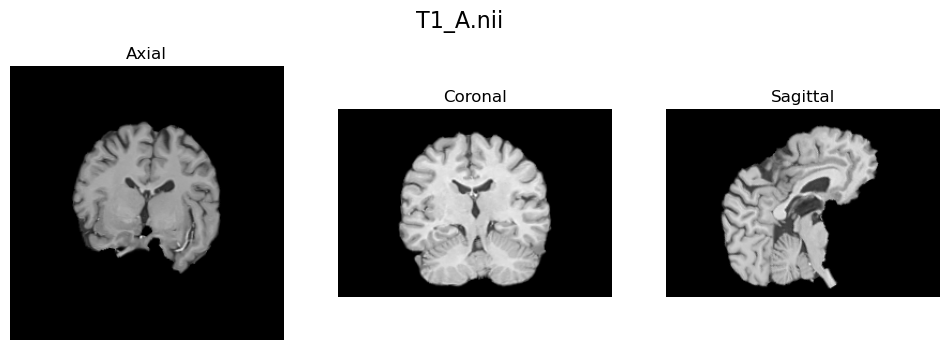

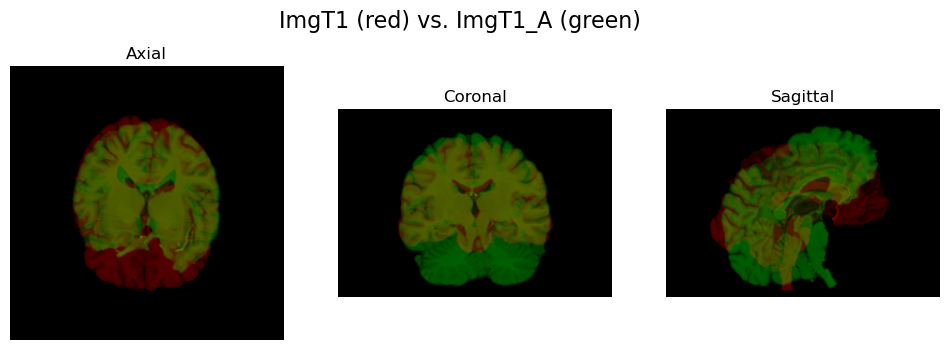

In [131]:
imshow_orthogonal_view(ImgT1_A, title="T1_A.nii")
moving_sitk = sitk.ReadImage(dir_in + "ImgT1_A.nii")
moving_np = sitk.GetArrayFromImage(moving_sitk)
overlay_slices(template_sitk, ImgT1_A, title="ImgT1 (red) vs. ImgT1_A (green)")

You also generate a mask by applying Otsu thresholding on the template volume. Then, apply a
morphological closing with a skimage.morphology.ball as a structuring element with radius 5. Finally,
apply erosion with a ball with a radius of 3.

In [132]:
template_masked = template_np * mask_np
moving_masked = moving_np * mask_np

In [133]:
mask_indices = mask_np > 0
f = template_masked[mask_indices]  # Flattened masked template
m = moving_masked[mask_indices]  # Flattened masked moving

if len(f) == 0:
    raise ValueError("Mask is empty; no valid pixels to compute NCC.")

# Compute means
f_mean = np.mean(f)
m_mean = np.mean(m)

# Compute numerator: sum((f - f_mean)(m - m_mean))
numerator = np.sum((f - f_mean) * (m - m_mean))

# Compute denominator: sqrt(sum((f - f_mean)^2) * sum((m - m_mean)^2))
denom_f = np.sum((f - f_mean) ** 2)
denom_m = np.sum((m - m_mean) ** 2)
denominator = np.sqrt(denom_f * denom_m)

# Avoid division by zero
if denominator == 0:
    raise ValueError("Denominator is zero; images may be constant in masked region.")

ncc = numerator / denominator
print(f"Normalized Correlation Coefficient (NCC): {ncc:.4f}")

Normalized Correlation Coefficient (NCC): 0.0993


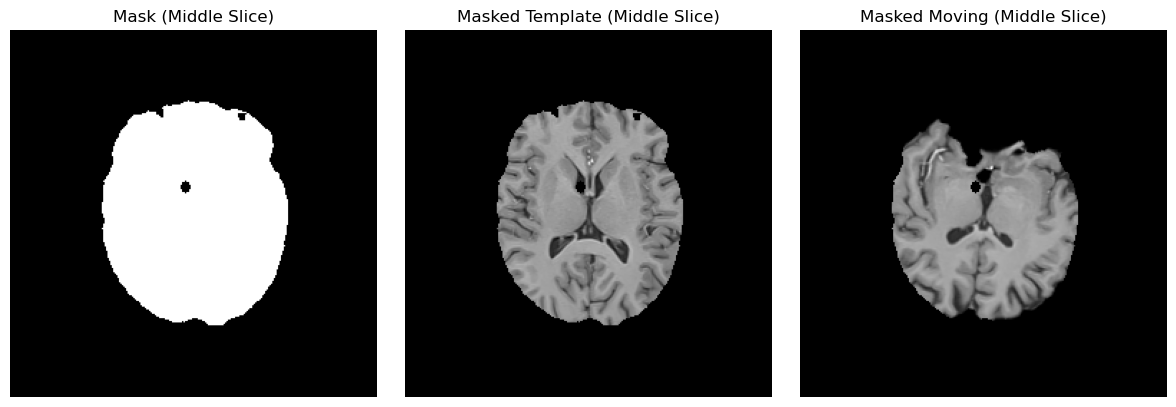

In [134]:
slice_idx = template_np.shape[0] // 2  # Middle slice
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(mask_np[slice_idx, :, :], cmap="gray")
plt.title("Mask (Middle Slice)")
plt.axis("off")

plt.subplot(132)
plt.imshow(template_masked[slice_idx, :, :], cmap="gray")
plt.title("Masked Template (Middle Slice)")
plt.axis("off")

plt.subplot(133)
plt.imshow(moving_masked[slice_idx, :, :], cmap="gray")
plt.title("Masked Moving (Middle Slice)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Optional: Save masked images back as NIfTI if needed
template_masked_sitk = sitk.GetImageFromArray(template_masked)
template_masked_sitk.CopyInformation(template_sitk)  # Preserve metadata
sitk.WriteImage(template_masked_sitk, dir_in + "template_masked.nii.gz")

moving_masked_sitk = sitk.GetImageFromArray(moving_masked)
moving_masked_sitk.CopyInformation(moving_sitk)
sitk.WriteImage(moving_masked_sitk, dir_in + "moving_masked.nii.gz")

In [137]:
# Optional: Save masked images back as NIfTI if needed
mask_sitk = sitk.GetImageFromArray(mask_np)
sitk.WriteImage(mask_sitk, dir_in + "mask.nii.gz")

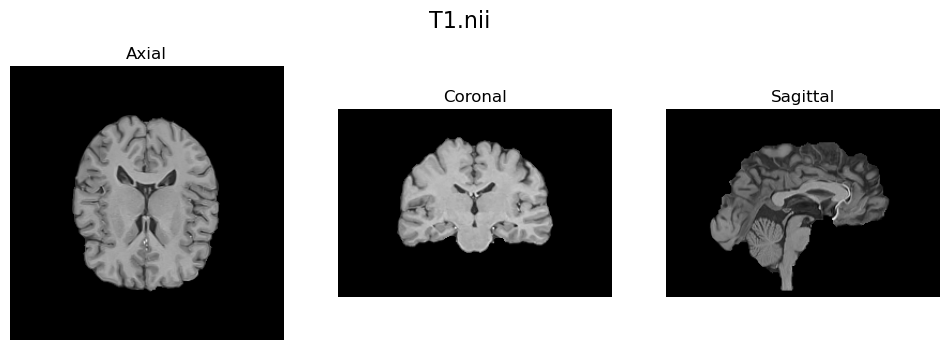

In [ ]:
dir_in = "brain/"
segmented_template_sitk = sitk.ReadImage("brain/mask.nii.gz")
# Display the volume
imshow_orthogonal_view(template_sitk, title="T1.nii")
template_np = sitk.GetArrayFromImage(segmented_template_sitk)

# Pots

/tmp/ipykernel_130418/1722712655.py:10: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  footprint = morphology.square(10)  # Define a 10x10 square footprint


Number of foreground pixels: 7324


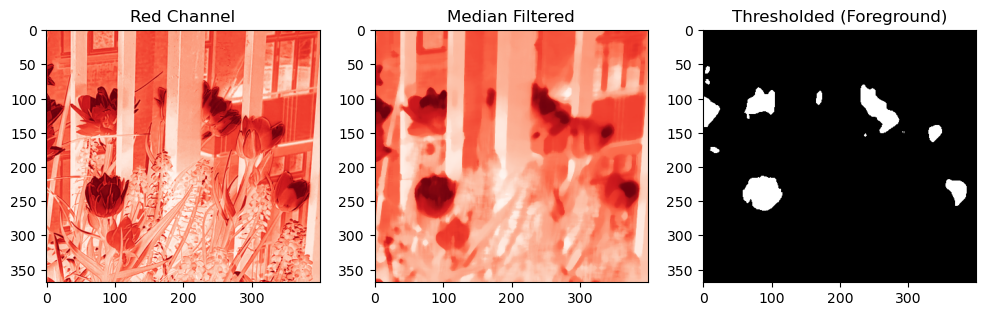

In [139]:
import numpy as np
from skimage import io, filters, morphology
import matplotlib.pyplot as plt

# Step 1: Load the image and extract the red channel
image = io.imread("pots/pots.jpg")  # Ensure 'pots.jpg' is in the working directory
red_channel = image[:, :, 0]  # Red channel (assuming RGB order)

# Step 2: Apply median filter with square footprint (size 10)
footprint = morphology.square(10)  # Define a 10x10 square footprint
median_filtered = filters.median(red_channel, footprint)

# Step 3: Threshold the image (foreground = pixels > 200)
threshold_value = 200
binary_image = (median_filtered > threshold_value).astype(np.uint8) * 255

# Step 4: Count foreground pixels (white pixels in binary_image)
foreground_pixels = np.sum(binary_image == 255)

# Output the result
print(f"Number of foreground pixels: {foreground_pixels}")

# Optional: Display the images for visualization
plt.figure(figsize=(12, 4))
plt.subplot(131), plt.imshow(red_channel, cmap="Reds"), plt.title("Red Channel")
plt.subplot(132), plt.imshow(median_filtered, cmap="Reds"), plt.title("Median Filtered")
plt.subplot(133), plt.imshow(binary_image, cmap="gray"), plt.title(
    "Thresholded (Foreground)"
)
plt.show()